# Revenue-at-Risk Analysis

This notebook combines customer churn probability and Customer Lifetime Value (CLV) predictions to calculate Revenue-at-Risk and identify the highest-priority customers for retention.

## 1. Business Understanding

Customer churn has an uneven impact: a churned high-value customer can cost much more than a churned low-value one. This analysis estimates the expected revenue at risk by combining each customer’s churn probability with their predicted lifetime value, then categorizes customers by risk and retention priority.

## 2. Import Libraries

Import the Python libraries used for data loading, analysis, and visualization.

In [14]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

DATA_DIR = Path('..') / 'data' / 'processed'
DATA_DIR.exists()

True

## 3. Load Data

Load the churn predictions and CLV predictions from the processed dataset files.

In [15]:
churn_path = DATA_DIR / 'customer_churn_predictions.csv'
clv_path = DATA_DIR / 'customer_clv_predictions.csv'

churn_df = pd.read_csv(churn_path)
clv_df = pd.read_csv(clv_path)

print('Churn data:', churn_df.shape)
print('CLV data:', clv_df.shape)

churn_df.head(3)

Churn data: (3365, 14)
CLV data: (3365, 15)


,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,Persona_ID,Customer_Persona,Churn,Churn_Probability
0,12346.0,325,1,77183.60,77183.60,1,1,5,115,Lost Customers,1,Active Customers,1,0.638875
1,12347.0,129,5,2790.86,558.17,4,4,5,445,Champions,2,VIP Customers,0,0.147440
2,12348.0,248,3,1487.24,495.75,2,4,4,244,At Risk,0,Dormant Customers,0,0.438221


## 4. Merge Churn & CLV

Merge the churn and CLV tables using `CustomerID` and keep the core prediction columns for Revenue-at-Risk calculation.

In [16]:
merge_cols = [
    'CustomerID',
    'Churn',
    'Churn_Probability',
    'Segment',
    'Persona_ID',
    'Customer_Persona'
]
clv_cols = [
    'CustomerID',
    'Future_CLV',
    'Log_Future_CLV',
    'Predicted_CLV'
]

merged_df = churn_df[merge_cols].merge(clv_df[clv_cols], on='CustomerID', how='inner')
merged_df['CustomerID'] = merged_df['CustomerID'].astype(int)

print('Merged dataset shape:', merged_df.shape)
merged_df.sample(5, random_state=42)

Merged dataset shape: (3365, 9)


,CustomerID,Churn,Churn_Probability,Segment,Persona_ID,Customer_Persona,Future_CLV,Log_Future_CLV,Predicted_CLV
1116,14262,0,0.364966,Champions,2,VIP Customers,1763.23,7.475470,105.154982
2358,16470,0,0.427444,Loyal Customers,2,VIP Customers,213.64,5.368962,43.062909
807,13728,0,0.237280,Champions,2,VIP Customers,219.12,5.394173,147.701806
2700,17088,0,0.432200,Need Attention,2,VIP Customers,591.90,6.385026,64.909393
196,12665,1,0.810817,Lost Customers,0,Dormant Customers,0.00,0.000000,1.739877


## 5. Revenue-at-Risk Calculation

Calculate the expected revenue at risk by multiplying each customer’s predicted CLV by their churn probability.

In [13]:
merged_df['Revenue_at_Risk'] = merged_df['Predicted_CLV'] * merged_df['Churn_Probability']
merged_df['Revenue_at_Risk'] = merged_df['Revenue_at_Risk'].fillna(0).clip(lower=0)
max_risk = merged_df["Revenue_at_Risk"].max()

if max_risk > 0:
    merged_df["Risk_Score"] = (
        merged_df["Revenue_at_Risk"] / max_risk
    )
else:
    merged_df["Risk_Score"] = 0
merged_df[['Predicted_CLV', 'Churn_Probability', 'Revenue_at_Risk', 'Risk_Score']].describe()

,Predicted_CLV,Churn_Probability,Revenue_at_Risk,Risk_Score
count,3365.000000,3365.000000,3365.000000,3365.000000
mean,303.035862,0.486302,33.310393,0.023384
std,1481.248640,0.215563,80.869812,0.056770
min,1.622230,0.022684,1.294646,0.000909
25%,8.148539,0.330052,5.452929,0.003828
50%,24.286254,0.530170,12.472664,0.008756
75%,124.401234,0.672177,38.836055,0.027263
max,25890.416230,0.813247,1424.518897,1.000000


## 6. Customer Risk Segmentation

Segment customers by revenue-at-risk and rank risk so retention resources can be focused on the highest-impact customers.

In [17]:
# ==========================================================
# Revenue-at-Risk Calculation
# ==========================================================

merged_df["Revenue_at_Risk"] = (
    merged_df["Predicted_CLV"]
    * merged_df["Churn_Probability"]
)

merged_df["Revenue_at_Risk"] = (
    merged_df["Revenue_at_Risk"]
    .fillna(0)
    .clip(lower=0)
)

# ==========================================================
# Risk Score (0-1 Normalization)
# ==========================================================

max_risk = merged_df["Revenue_at_Risk"].max()

if max_risk > 0:
    merged_df["Risk_Score"] = (
        merged_df["Revenue_at_Risk"] / max_risk
    )
else:
    merged_df["Risk_Score"] = 0

# ==========================================================
# Risk Category
# ==========================================================

merged_df["Risk_Category"] = pd.qcut(

    merged_df["Revenue_at_Risk"],

    q=4,

    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Critical Risk"
    ],

    duplicates="drop"

)

# ==========================================================
# Customer Retention Action
# ==========================================================

priority_conditions = [

    (
        (merged_df["Churn_Probability"] >= 0.70)
        &
        (merged_df["Risk_Category"] == "Critical Risk")
    ),

    (
        (merged_df["Churn_Probability"] >= 0.50)
        &
        (
            merged_df["Risk_Category"].isin(
                ["High Risk", "Critical Risk"]
            )
        )
    ),

    (
        merged_df["Churn_Probability"] >= 0.30
    ),

    (
        merged_df["Churn_Probability"] < 0.30
    )

]

priority_values = [

    "Critical Retention",

    "High Retention",

    "Elevated Risk",

    "Monitor"

]

merged_df["Customer_Action"] = np.select(

    priority_conditions,

    priority_values,

    default="Monitor"

)

# ==========================================================
# Summary Statistics
# ==========================================================

print("=" * 60)
print("Revenue-at-Risk Summary")
print("=" * 60)

print(
    merged_df[
        [
            "Predicted_CLV",
            "Churn_Probability",
            "Revenue_at_Risk",
            "Risk_Score"
        ]
    ].describe()
)

print("\nRisk Category Distribution\n")

print(
    merged_df["Risk_Category"].value_counts()
)

print("\nCustomer Action Distribution\n")

print(
    merged_df["Customer_Action"].value_counts()
)

print("\nRevenue-at-Risk by Category\n")

print(

    merged_df.groupby("Risk_Category").agg(

        Customers=("CustomerID", "count"),

        Average_Risk=("Revenue_at_Risk", "mean"),

        Total_Revenue_At_Risk=("Revenue_at_Risk", "sum")

    )

)

# ==========================================================
# Preview Final Dataset
# ==========================================================

merged_df[
    [
        "CustomerID",
        "Predicted_CLV",
        "Churn_Probability",
        "Revenue_at_Risk",
        "Risk_Category",
        "Customer_Action"
    ]
].head(10)

Revenue-at-Risk Summary
       Predicted_CLV  Churn_Probability  Revenue_at_Risk   Risk_Score
count    3365.000000        3365.000000      3365.000000  3365.000000
mean      303.035862           0.486302        33.310393     0.023384
std      1481.248640           0.215563        80.869812     0.056770
min         1.622230           0.022684         1.294646     0.000909
25%         8.148539           0.330052         5.452929     0.003828
50%        24.286254           0.530170        12.472664     0.008756
75%       124.401234           0.672177        38.836055     0.027263
max     25890.416230           0.813247      1424.518897     1.000000

Risk Category Distribution

Risk_Category
Low Risk         842
Medium Risk      841
High Risk        841
Critical Risk    841
Name: count, dtype: int64

Customer Action Distribution

Customer_Action
Elevated Risk     2445
Monitor            724
High Retention     196
Name: count, dtype: int64

Revenue-at-Risk by Category

               Custom

,CustomerID,Predicted_CLV,Churn_Probability,Revenue_at_Risk,Risk_Category,Customer_Action
0,12346,19.416396,0.638875,12.404651,Medium Risk,Elevated Risk
1,12347,393.605693,0.147440,58.033142,Critical Risk,Monitor
2,12348,55.950604,0.438221,24.518707,High Risk,Elevated Risk
3,12350,4.608591,0.757244,3.489826,Low Risk,Elevated Risk
4,12352,153.868665,0.326208,50.193238,Critical Risk,Elevated Risk
5,12353,3.278577,0.676259,2.217166,Low Risk,Elevated Risk
6,12354,14.404540,0.671518,9.672904,Medium Risk,Elevated Risk
7,12355,7.867080,0.670646,5.276023,Low Risk,Elevated Risk
8,12356,55.767722,0.534640,29.815643,High Risk,High Retention
9,12358,16.018102,0.562730,9.013871,Medium Risk,Elevated Risk


## 7. Exploratory Analysis

Analyze the Revenue-at-Risk distribution, the highest-risk customers, and the segments that deserve priority retention focus.

Top 10 Customers by Revenue-at-Risk


,CustomerID,Predicted_CLV,Churn_Probability,Revenue_at_Risk,Risk_Category,Customer_Action
2472,16684,14413.396247,0.098833,1424.518897,Critical Risk,Monitor
46,12415,22728.702397,0.061299,1393.253781,Critical Risk,Monitor
2893,17450,25890.416230,0.049228,1274.540845,Critical Risk,Monitor
1345,14646,24336.187209,0.048463,1179.401448,Critical Risk,Monitor
3259,18102,23071.894346,0.050204,1158.303050,Critical Risk,Monitor
355,12931,10139.915491,0.100374,1017.780821,Critical Risk,Monitor
1053,14156,23774.643653,0.042543,1011.445265,Critical Risk,Monitor
1016,14088,7730.156361,0.125216,967.938586,Critical Risk,Monitor
2865,17404,8014.270060,0.103785,831.762308,Critical Risk,Monitor
1364,14680,8492.118766,0.092760,787.731931,Critical Risk,Monitor


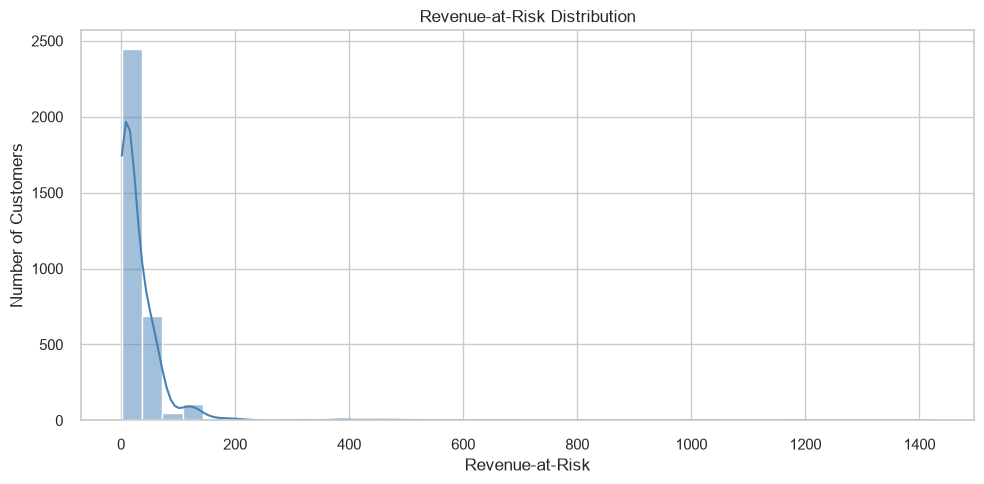

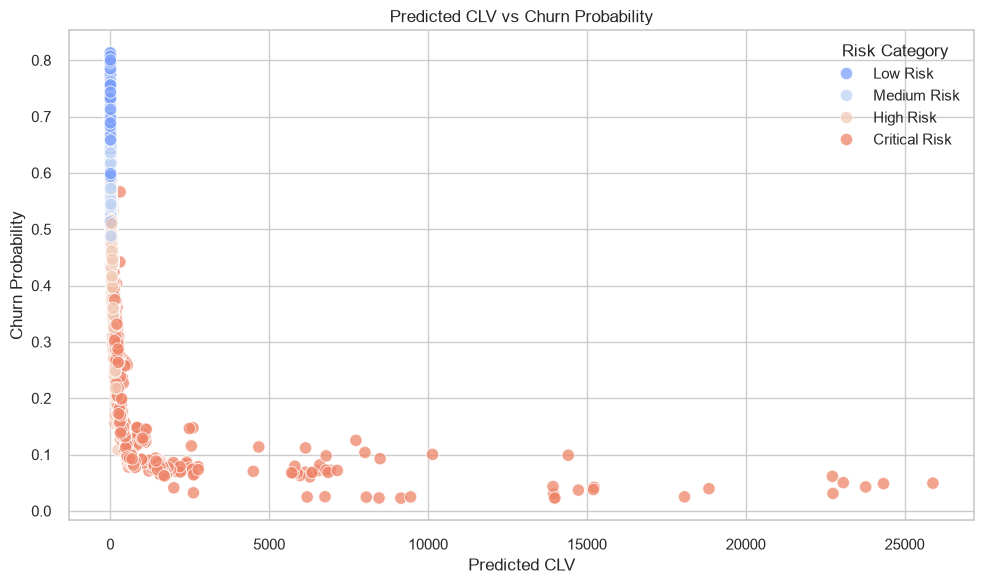

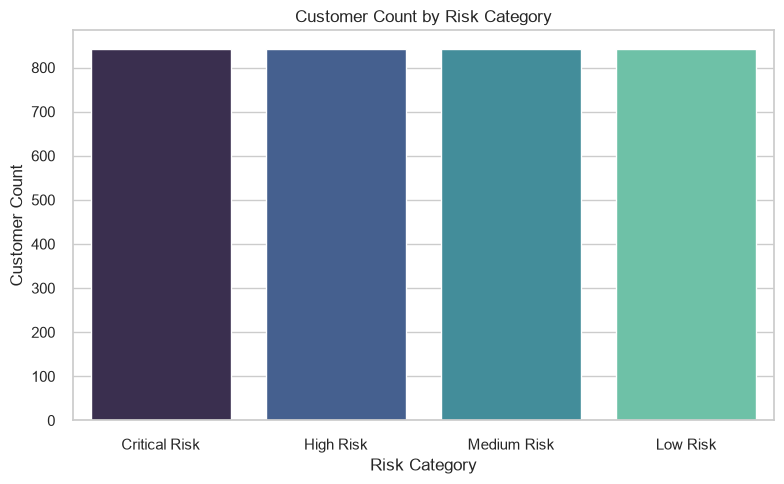

,Customer_Action,Customers,Total_Revenue_At_Risk,Average_Revenue_At_Risk
0,Elevated Risk,2445,33255.012025,13.601232
1,High Retention,196,3692.625643,18.839927
2,Monitor,724,75141.834171,103.787064


,Customers,Total_Revenue_At_Risk,Average_Churn,Average_CLV
Segment,,,,
Champions,761,72215.557746,0.182133,1183.515096
Need Attention,651,17301.505142,0.469199,109.449749
Lost Customers,1169,8396.310152,0.691204,11.414889
Potential Loyalists,468,6354.785338,0.523786,27.877180
At Risk,177,5278.763510,0.440277,85.022857
Loyal Customers,139,2542.549952,0.440838,45.822506


,Customers,Total_Revenue_At_Risk,Average_CLV,Average_Churn
Customer_Persona,,,,
VIP Customers,2145,89173.568430,308.796873,0.384936
Active Customers,25,13061.583894,13578.227858,0.060048
Dormant Customers,1195,9854.319515,14.971285,0.677169


In [18]:
# ==========================================================
# Top 10 Customers by Revenue-at-Risk
# ==========================================================

top_risk = (

    merged_df

    .sort_values(

        "Revenue_at_Risk",

        ascending=False

    )

    .head(10)

)

print("Top 10 Customers by Revenue-at-Risk")

display(

    top_risk[

        [

            "CustomerID",

            "Predicted_CLV",

            "Churn_Probability",

            "Revenue_at_Risk",

            "Risk_Category",

            "Customer_Action"

        ]

    ]

)

# ==========================================================
# Revenue-at-Risk Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(

    merged_df["Revenue_at_Risk"],

    bins=40,

    kde=True,

    color="steelblue"

)

plt.title("Revenue-at-Risk Distribution")

plt.xlabel("Revenue-at-Risk")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

# ==========================================================
# CLV vs Churn Probability
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=merged_df,

    x="Predicted_CLV",

    y="Churn_Probability",

    hue="Risk_Category",

    palette="coolwarm",

    alpha=0.75,

    edgecolor="white",

    s=80

)

plt.title(

    "Predicted CLV vs Churn Probability"

)

plt.xlabel("Predicted CLV")

plt.ylabel("Churn Probability")

plt.legend(title="Risk Category")

plt.tight_layout()

plt.show()

# ==========================================================
# Customer Count by Risk Category
# ==========================================================

plt.figure(figsize=(8,5))

risk_counts = (

    merged_df["Risk_Category"]

    .value_counts()

    .reindex(

        [

            "Critical Risk",

            "High Risk",

            "Medium Risk",

            "Low Risk"

        ]

    )

)

sns.barplot(

    x=risk_counts.index,

    y=risk_counts.values,

    palette="mako"

)

plt.title("Customer Count by Risk Category")

plt.xlabel("Risk Category")

plt.ylabel("Customer Count")

plt.tight_layout()

plt.show()

# ==========================================================
# Revenue-at-Risk by Customer Action
# ==========================================================

action_summary = (

    merged_df

    .groupby(

        "Customer_Action"

    )

    .agg(

        Customers=("CustomerID","count"),

        Total_Revenue_At_Risk=("Revenue_at_Risk","sum"),

        Average_Revenue_At_Risk=("Revenue_at_Risk","mean")

    )

    .reset_index()

)

display(action_summary)

# ==========================================================
# Revenue-at-Risk by RFM Segment
# ==========================================================

segment_summary = (

    merged_df

    .groupby("Segment")

    .agg(

        Customers=("CustomerID","count"),

        Total_Revenue_At_Risk=("Revenue_at_Risk","sum"),

        Average_Churn=("Churn_Probability","mean"),

        Average_CLV=("Predicted_CLV","mean")

    )

    .sort_values(

        "Total_Revenue_At_Risk",

        ascending=False

    )

)

display(segment_summary)

# ==========================================================
# Revenue-at-Risk by Customer Persona
# ==========================================================

persona_summary = (

    merged_df

    .groupby("Customer_Persona")

    .agg(

        Customers=("CustomerID","count"),

        Total_Revenue_At_Risk=("Revenue_at_Risk","sum"),

        Average_CLV=("Predicted_CLV","mean"),

        Average_Churn=("Churn_Probability","mean")

    )

    .sort_values(

        "Total_Revenue_At_Risk",

        ascending=False

    )

)

display(persona_summary)

## 8. Business Insights

* Revenue-at-Risk combines predicted Customer Lifetime Value (CLV) and churn probability to estimate the expected financial loss associated with each customer, enabling businesses to prioritize retention efforts based on financial impact rather than churn probability alone.

* Customers classified as **Critical Risk** represent the highest-value retention opportunities because they simultaneously exhibit high predicted lifetime value and a high likelihood of churn. Retaining these customers can significantly reduce future revenue loss.

* The **Customer Action** framework translates predictive analytics into business decisions by categorizing customers into **Critical Retention**, **High Retention**, **Elevated Risk**, and **Monitor** groups, allowing marketing teams to allocate retention budgets more efficiently.

* Segment-level and customer persona analyses identify which customer groups contribute the greatest share of Revenue-at-Risk. These insights enable businesses to design targeted retention campaigns instead of applying a single strategy to all customers.

* The Top Revenue-at-Risk customers should be prioritized for personalized retention initiatives such as loyalty rewards, exclusive offers, proactive customer support, or dedicated account management.

* By integrating the outputs of the Churn Prediction and Customer Lifetime Value models, the Revenue-at-Risk framework provides a practical decision-support tool for customer retention planning, marketing optimization, and long-term revenue protection.


## 9. Business Conclusion

The Revenue-at-Risk analysis successfully integrated the outputs of the Customer Churn Prediction and Customer Lifetime Value models into a unified business decision framework. By estimating the expected revenue loss associated with each customer, the analysis enables organizations to identify high-value customers who require immediate retention efforts.

Customers were categorized into actionable risk groups and mapped to corresponding retention strategies, transforming predictive analytics into practical business recommendations. The resulting dataset provides a prioritized customer list that supports targeted marketing campaigns, efficient allocation of retention resources, and long-term revenue protection.


## 10. Save Dataset

Save the enriched Revenue-at-Risk dataset for downstream reporting and retention action planning.

In [19]:
output_path = DATA_DIR / 'revenue_at_risk_analysis.csv'
merged_df.to_csv(output_path, index=False)
print(f'Saved Revenue-at-Risk dataset to: {output_path}')
merged_df.head(3)

Saved Revenue-at-Risk dataset to: ..\data\processed\revenue_at_risk_analysis.csv


,CustomerID,Churn,Churn_Probability,Segment,Persona_ID,Customer_Persona,Future_CLV,Log_Future_CLV,Predicted_CLV,Revenue_at_Risk,Risk_Score,Risk_Category,Customer_Action
0,12346,1,0.638875,Lost Customers,1,Active Customers,0.00,0.000000,19.416396,12.404651,0.008708,Medium Risk,Elevated Risk
1,12347,0,0.147440,Champions,2,VIP Customers,1519.14,7.326558,393.605693,58.033142,0.040739,Critical Risk,Monitor
2,12348,0,0.438221,At Risk,0,Dormant Customers,310.00,5.739793,55.950604,24.518707,0.017212,High Risk,Elevated Risk
